In [14]:
## Load in the confocal data
import pandas as pd

## Results dataframes
confocal_df = pd.read_csv("confocal_full_results.csv")
idealised_df = pd.read_csv("idealised_chosen_results.csv")

## Set the colours for the three mesh types
colours = {
    'realistic': 'blue',
    'simplified_circular': 'orange',
    'simplified_oval': 'green'
}

## Set font size for all plots
import matplotlib.pyplot as plt

# Set the default font size for all plots
plt.rcParams.update({'font.size': 14})


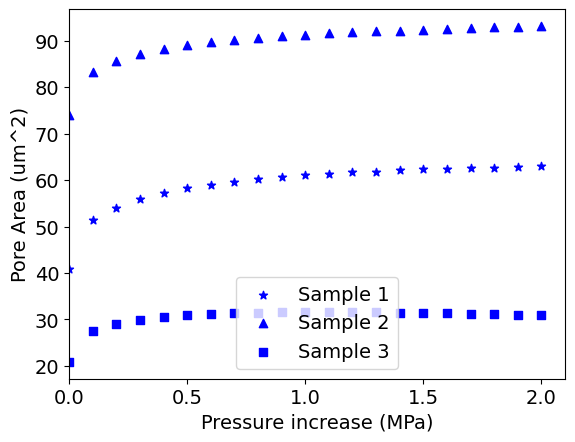

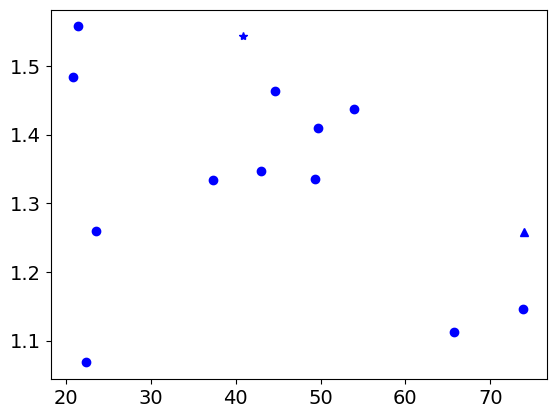

In [23]:
## Figure 1: FEM models of stomata using realistic geometry open without anisotropic stiffening or polar pinning
import matplotlib.pyplot as plt

sample_meshes = ["1_2","2_3","3_2"]
all_meshes = confocal_df["Mesh ID"].unique()
mesh_names = ["Sample 1","Sample 2","Sample 3"]
symbols = ["*","^","s"]

## Plot pressure vs pore area for each of the sample meshes
for mesh, symbol, mesh_name in zip(sample_meshes, symbols, mesh_names):
    data = confocal_df[confocal_df["Mesh ID"] == mesh]
    plt.scatter(data["Pressure"],data["Pore Area"], marker=symbol, label=mesh_name, color = colours["realistic"])
plt.xlabel("Pressure increase (MPa)")
plt.ylabel("Pore Area (um^2)")
plt.xlim(0,2.1)
plt.legend()
plt.show()

## Plot starting pore area vs end pore area / start pore area. Highlight the three selected meshes
for mesh in all_meshes:
    data = confocal_df[confocal_df["Mesh ID"]==mesh]
    start_pore = data[data["Pressure"]==0]["Pore Area"].values[0]
    end_pore = data[data["Pressure"]==2.0]["Pore Area"].values[0]
    if mesh == sample_meshes[0]: marker = symbols[0]
    elif mesh == sample_meshes[1]: marker = symbols[1]
    elif mesh == sample_meshes[2]: maker = symbols[2]
    else: marker = "o"

    plt.plot(start_pore, end_pore/start_pore,marker=marker, color = colours['realistic'])

plt.show()